## Neural Sorting

This project explores the concept of sorting using neural networks.


## Loss function

The loss function compute the total entropy of a vector of numbers.
Entropy in this context must be interpreted as a measure of disorder, less the entropy, more ordered the vector is. The loss function is defined as follows:

`loss(x) = sum(|x_i - x_(i-1)|)
starting from i=1
`

Basically the loss function is the reduction sum of the absolute value of differences between each consecutive pair of elements in the vector.

## 3 Scenarios

### Scenario 1: Learn how to sort a specific permutation of the same vector
### Scenario 2: Learn how to sort a specific set of numbers
### Scenario 3: Learn how to generalize to arbitrary set of numbers

## Scenario 1: Learn how to sort a specific permutation of the same vector

The whole scenario consist in train the network to learn a specific permutation matrix that if applied to a specific vector, it will sort it. 

In [1]:
"""Model architecture"""

from thorcino.optimizer import SGD
from thorcino.training import CosineSchedule, Trainer
from thorcino.layers import Sequential, Linear
from loss import PermutationLoss

SEED = 777
VECT_LENGTH = 5
EPOCHS, EVAL_STEP = 500, 10
MAX_LR, MIN_LR = 1e-3, 1e-6

model = Sequential(
    Linear(VECT_LENGTH, VECT_LENGTH)
)
loss = PermutationLoss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(
    model,
    loss,
    optimizer,
    scheduler
)

In [ ]:
import numpy as np
from loss import perm_matrix
from thorcino.tensor import Tensor

rng = np.random.default_rng(SEED)

input = rng.standard_normal(VECT_LENGTH)
target = np.sort(input)
perm_target = perm_matrix(input, target)

input, target = Tensor(input), Tensor(target)

tr_loss_history = []
for i in range(EPOCHS):
    pred = model(input)
    tr_loss = loss.forward(input, pred, target)
    tr_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    optimizer.lr = scheduler.get_lr(i)

    tr_loss_history.append(tr_loss.data)

print(f"input={input.data}")
print(f"predictions={pred.data}")
print(f"target={target.data}")
print('------------------------------------------------')
print(f"last loss={tr_loss_history[-1]}")
print('------------------------------------------------')
print(model.parameters[0].data)

input=[-0.8475155   0.06854253 -1.250926   -1.5836366   0.6324576 ]
predictions=[ 1.266417    0.7558645  -0.90096843  0.1652736  -0.23582935]
target=[-1.5836366  -1.250926   -0.8475155   0.06854253  0.6324576 ]
------------------------------------------------
last loss=-5.0
------------------------------------------------
[[-0.04210223 -0.48753393  0.40000904  0.06008462 -0.9393027 ]
 [ 0.23872665 -0.67459196  0.7325167   0.28647038  0.5438677 ]
 [-0.60156584 -0.2870353   0.21147992  0.8014556  -0.03933739]
 [-0.2592189  -0.17216381 -0.07200401 -1.0636683   0.59851754]
 [ 0.08118945 -0.3838909  -0.7299233  -0.76738983 -0.26967007]]


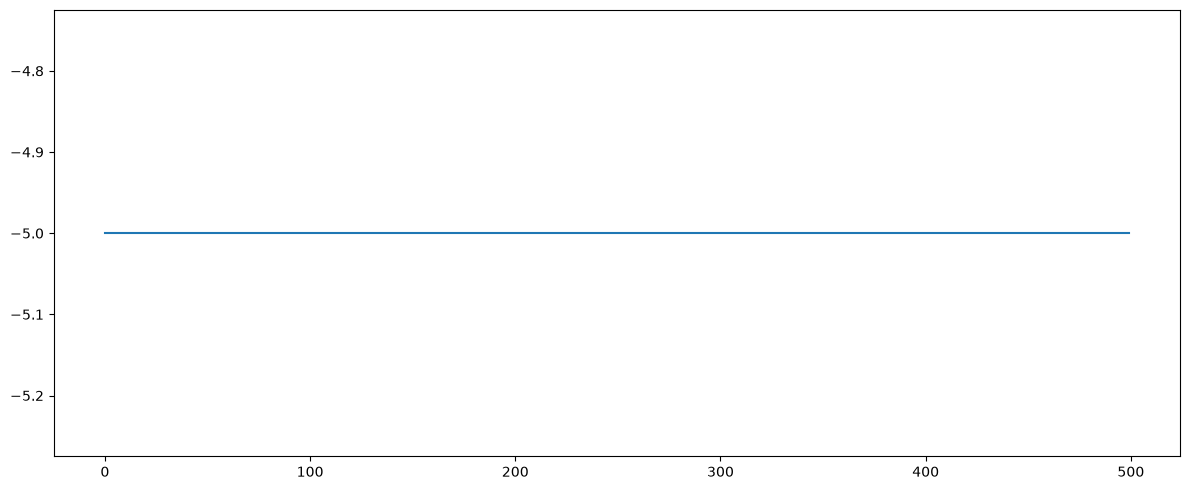

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), tr_loss_history)

fig.tight_layout()
plt.show()